In [ ]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
from datasets import load_dataset

from src.model_loader import load_model
from src.intervention import (
    load_direction, gap_from_metadata,
    score_dataset, run_recovery, recovery_table,
    _make_ablation_fn, make_translation_fn
)

# forget10 is the split your checkpoints were unlearned on.
tofu = load_dataset("locuslab/TOFU", "forget10")["train"]

forget_prompts = [ex["question"] for ex in tofu]
forget_answers = [ex["answer"]   for ex in tofu]

print(f"{len(forget_prompts)} forget pairs")
print("example Q:", forget_prompts[0])
print("example A:", forget_answers[0])


400 forget pairs
example Q: What is the full name of the author born in Taipei, Taiwan on 05/11/1991 who writes in the genre of leadership?
example A: The author's full name is Hsiao Yun-Hwa.


In [2]:
CHECKPOINTS = {
    "GradDiff": "open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_GradDiff_lr1e-05_alpha5_epoch5",
    "NPO":      "open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_NPO_lr1e-05_beta0.5_alpha1_epoch10",
    "AltPO":    "open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_AltPO_lr5e-05_beta0.1_alpha1_epoch10",
    "SimNPO":   "open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_SimNPO_lr2e-05_b4.5_a1_d1_g0.125_ep10",
    "RMU":      "open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_RMU_lr5e-05_layer10_scoeff10_epoch10",
}
RETAIN = "open-unlearning/tofu_Llama-3.2-1B-Instruct_retain90"
BASE_MODEL = "open-unlearning/tofu_Llama-3.2-1B-Instruct_full"


Run Retain Model as Oracle/Baseline for True Ignorance

In [3]:
# Load oracle, score the same forget pairs with no hook, then free it.
o_model, o_tok, o_dev = load_model(RETAIN)
oracle_lps = score_dataset(o_model, o_tok, o_dev, forget_prompts, forget_answers)
ORACLE = float(oracle_lps.mean())
print(f"oracle reference (this scorer): {ORACLE:+.4f}")

del o_model, o_tok          # free MPS memory before the real run
import gc, torch; gc.collect()
if torch.backends.mps.is_available(): torch.mps.empty_cache()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/tofu_Llama-3.2-1B-Instruct_retain90
Device: mps | dtype: torch.float16
Params: 1.2B
oracle reference (this scorer): -2.5720


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_GradDiff_lr1e-05_alpha5_epoch5
Device: mps | dtype: torch.float16
Params: 1.2B


/Users/anie/Projects/unlearning-probes/src/intervention.py:130: UserWarning: MPS mm implementation has a known issue with this shape, dtype and slice. Dispatching to metal implementation instead. This may impact performance. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/mps/operations/LinearAlgebra.mm:322.)
  proj = torch.matmul(hidden, d)              # (batch, seq)


[GradDiff] layer 14 | baseline -0.734 | ablated -0.734 | random-shift -0.002 | signed/abs -0.000/0.003 | recovered 0/400


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

...

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_AltPO_lr5e-05_beta0.1_alpha1_epoch10
Device: mps | dtype: torch.float16
Params: 1.2B
[AltPO] layer 14 | baseline -3.281 | ablated -3.282 | random-shift -0.002 | signed/abs -0.001/0.020 | recovered 0/400


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_SimNPO_lr2e-05_b4.5_a1_d1_g0.125_ep10
Device: mps | dtype: torch.float16
Params: 1.2B
[SimNPO] layer 14 | baseline -1.394 | ablated -1.396 | random-shift -0.003 | signed/abs -0.002/0.008 | recovered 0/400


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_RMU_lr5e-05_layer10_scoeff10_epoch10
Device: mps | dtype: torch.float16
Params: 1.2B
[RMU] layer 10 | baseline -7.917 | ablated -7.718 | random-shift +0.018 | signed/abs +0.198/0.229 | recovered 0/400

Saved all results to ../results/ablation_recovery/recovery_all_models.json
model      layer    base  ablated  oracle  signed    abs    std   recov
-----------------------------------------------------------------------
GradDiff      14   -0.73    -0.73   -2.57   -0.00   0.00   0.00   0/400
NPO           14   -1.00    -1.00   -2.57   -0.00   0.00   0.01   0/400
AltPO         14   -3.28    -3.28   -2.57   -0.00   0.02   0.03   0/400
SimNPO        14   -1.39    -1.40   -2.57   -0.00   0.01   0.01   0/400
RMU           10   -7.92    -7.72   -2.57   +0.20   0.23   0.20   0/400
Saved figure to ../results/ablation_recovery/recovery_hist.png
Saved figure to ../results/ablation_recovery/recovery_means.png


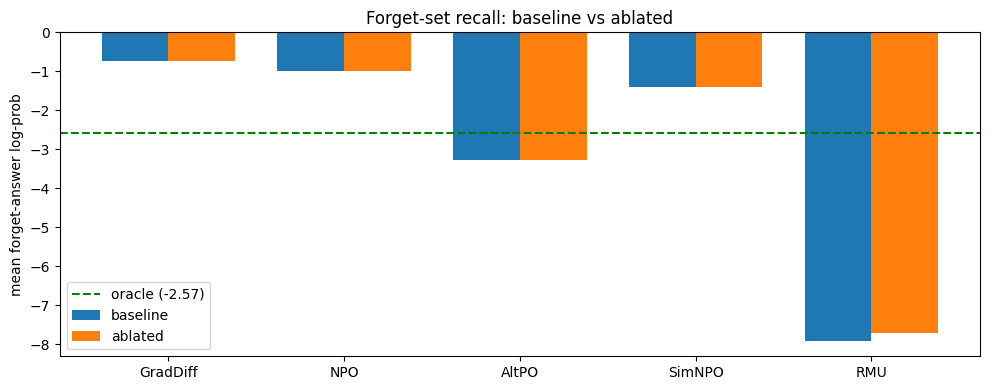

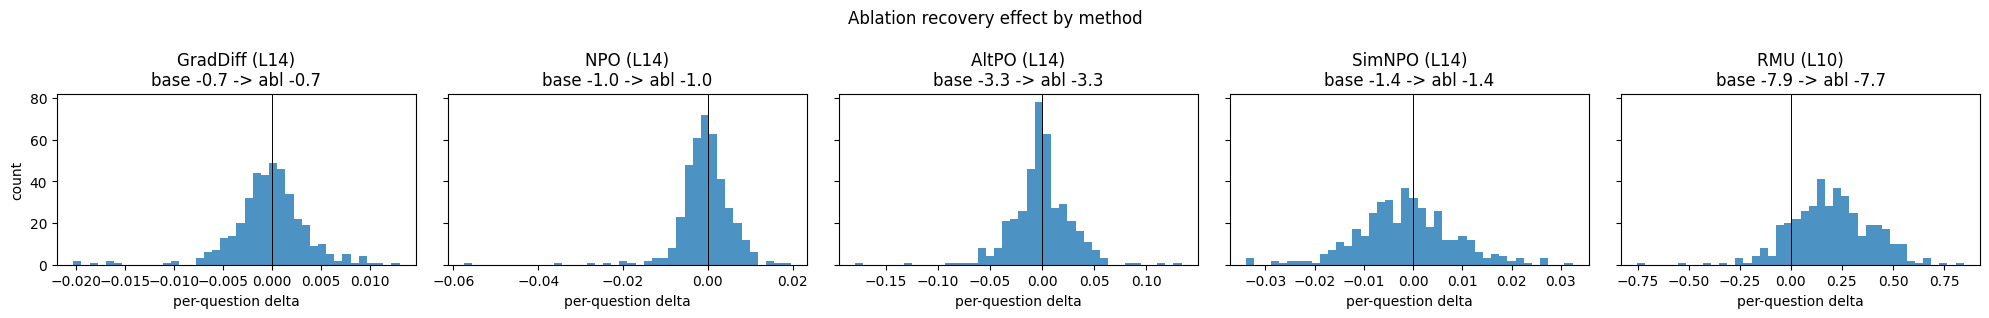

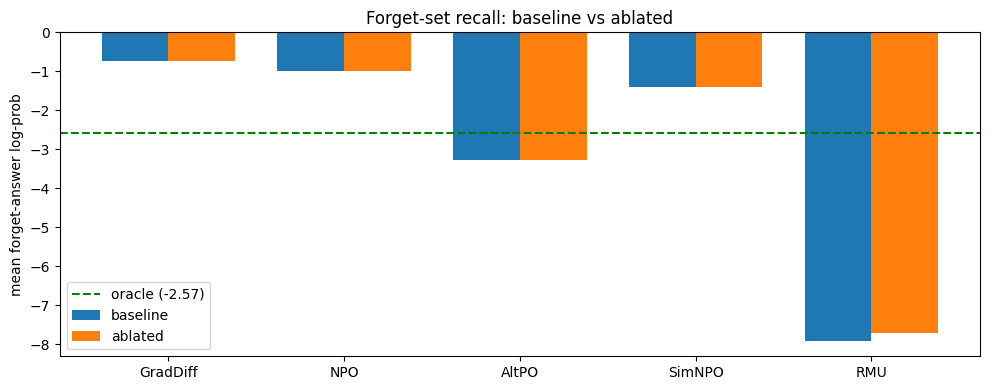

In [5]:
from src.recovery_experiment import run_all_models, summarize_table, plot_recovery, plot_means_vs_oracle

MODEL_LAYER_DICT = {k: 14 for k in CHECKPOINTS}
MODEL_LAYER_DICT["RMU"] = 10

results = run_all_models(
    model_layers=MODEL_LAYER_DICT,
    checkpoints=CHECKPOINTS,
    forget_prompts=forget_prompts,
    forget_answers=forget_answers,
    oracle_ref=ORACLE,
    out_path="../results/ablation_recovery/recovery_all_models.json",
    use_best_layer=False,    # use provided layers since we know RMU should be at intervention layer
)

summarize_table(results)
plot_recovery(results, save_path="../results/ablation_recovery/recovery_hist.png")
plot_means_vs_oracle(results, save_path="../results/ablation_recovery/recovery_means.png")

In [6]:
import numpy as np, torch
from src.intervention import _intervention_hook, _make_ablation_fn, _score_one, load_direction

model, tok, dev = load_model(CHECKPOINTS["AltPO"])
d_altpo = load_direction("../data/sweep_altpo/layer14/direction.npy")
print("direction norm:", np.linalg.norm(d_altpo))   # should be 1.0

rng = np.random.default_rng(0)
rand = rng.standard_normal(d_altpo.shape[0]); rand /= np.linalg.norm(rand)
p, a = forget_prompts[0], forget_answers[0]

clean = _score_one(model, tok, dev, p, a)
with _intervention_hook(model, "model.layers.14", _make_ablation_fn(rand)):
    r = _score_one(model, tok, dev, p, a)
with _intervention_hook(model, "model.layers.14", _make_ablation_fn(d_altpo)):
    real = _score_one(model, tok, dev, p, a)
print(f"clean {clean:+.3f} | random {r-clean:+.3f} | real-abl {real-clean:+.3f}")

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_AltPO_lr5e-05_beta0.1_alpha1_epoch10
Device: mps | dtype: torch.float16
Params: 1.2B
direction norm: 1.0
clean -7.065 | random -0.009 | real-abl -0.036


In [7]:
import torch
from src.intervention import _intervention_hook, _make_ablation_fn

dt = torch.tensor(d_altpo, dtype=torch.float16, device=dev)
ids = tok(forget_prompts[0], return_tensors="pt").to(dev)
mods = dict(model.named_modules())

cap = {}
def grab(_m,_i,out):
    t = out[0] if isinstance(out,tuple) else out
    cap["proj"] = float(t[0,-1] @ dt)
    cap["norm"] = float(t[0,-1].norm())

# clean
h = mods["model.layers.14"].register_forward_hook(grab)
with torch.no_grad(): model(**ids)
h.remove()
print(f"CLEAN  layer14: proj onto d = {cap['proj']:.4f} | activation norm = {cap['norm']:.2f}")

# ablated — capture AFTER intervention
with _intervention_hook(model, "model.layers.14", _make_ablation_fn(d_altpo)):
    h = mods["model.layers.14"].register_forward_hook(grab)
    with torch.no_grad(): model(**ids)
    h.remove()
print(f"ABLATED layer14: proj onto d = {cap['proj']:.4f} | activation norm = {cap['norm']:.2f}")

CLEAN  layer14: proj onto d = 0.6938 | activation norm = 13.42
ABLATED layer14: proj onto d = -0.0001 | activation norm = 13.40


In [8]:
import numpy as np
for k in ["GradDiff","NPO","AltPO","SimNPO"]:
    dd = np.load(f"../data/sweep_{k.lower()}/layer14/direction.npy")
    print(k, "norm", round(float(np.linalg.norm(dd)),3), "first3", dd[:3].round(4))

GradDiff norm 1.0 first3 [ 0.0125 -0.0198  0.0555]
NPO norm 1.0 first3 [ 0.0159 -0.0142  0.0505]
AltPO norm 1.0 first3 [ 0.0389 -0.0005  0.0147]
SimNPO norm 1.0 first3 [ 0.0087 -0.0169  0.0599]


In [9]:
np.array(score_dataset(model, tok, dev, forget_prompts, forget_answers)).mean()

np.float64(-3.281396279421713)

In [13]:
from src.intervention import (
    diff_in_means_direction, _intervention_hook,
    _make_ablation_fn, _score_one, score_dataset,
)
from datasets import load_dataset
import numpy as np

retain_tofu    = load_dataset("locuslab/TOFU", "retain90")["train"]
retain_prompts = [ex["question"] for ex in retain_tofu]

# Run on the two methods that actually suppressed.
from tqdm import tqdm
for model_key, layer in tqdm([("RMU", 10), ("AltPO", 14), ("SimNPO", 14), ("NPO", 14)], desc="Models/Layers"):
    model, tok, dev = load_model(CHECKPOINTS[model_key])
    layer_name = f"model.layers.{layer}"

    # Difference-in-means direction (raw space, unit-normalized)
    d_diff = diff_in_means_direction(
        model, tok, dev, forget_prompts, retain_prompts, layer_name
    )

    # Full-dataset ablation with this direction
    baseline = score_dataset(model, tok, dev, forget_prompts, forget_answers)
    ablated  = score_dataset(
        model, tok, dev, forget_prompts, forget_answers,
        layer_name=layer_name, intervention_fn=_make_ablation_fn(d_diff),
    )

    # Confirm the direction was actually removed (the proof the edit landed)
    import torch
    dt = torch.tensor(d_diff, dtype=torch.float16, device=dev)
    ids = tok(forget_prompts[0], return_tensors="pt").to(dev)
    mods = dict(model.named_modules())
    cap = {}
    def grab(_m,_i,out):
        t = out[0] if isinstance(out,tuple) else out
        cap["proj"] = float(t[0,-1] @ dt)
    with _intervention_hook(model, layer_name, _make_ablation_fn(d_diff)):
        h = mods[layer_name].register_forward_hook(grab)
        with torch.no_grad(): model(**ids)
        h.remove()

    print(f"[{model_key} L{layer}] diff-in-means: "
          f"baseline {baseline.mean():+.3f} -> ablated {ablated.mean():+.3f} "
          f"(Δ {ablated.mean()-baseline.mean():+.3f}) | "
          f"proj-after-ablation {cap['proj']:.4f} (should be ~0)")

    del model
    import gc; gc.collect()
    if torch.backends.mps.is_available(): torch.mps.empty_cache()

Models/Layers:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_RMU_lr5e-05_layer10_scoeff10_epoch10
Device: mps | dtype: torch.float16
Params: 1.2B


Models/Layers:  25%|██▌       | 1/4 [01:22<04:08, 82.75s/it]

[RMU L10] diff-in-means: baseline -7.917 -> ablated -2.243 (Δ +5.674) | proj-after-ablation -0.0009 (should be ~0)


...

[SimNPO L14] diff-in-means: baseline -1.394 -> ablated -1.434 (Δ -0.040) | proj-after-ablation 0.0007 (should be ~0)


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_NPO_lr1e-05_beta0.5_alpha1_epoch10
Device: mps | dtype: torch.float16
Params: 1.2B


Models/Layers: 100%|██████████| 4/4 [05:30<00:00, 82.64s/it]

[NPO L14] diff-in-means: baseline -0.997 -> ablated -0.996 (Δ +0.002) | proj-after-ablation -0.0005 (should be ~0)


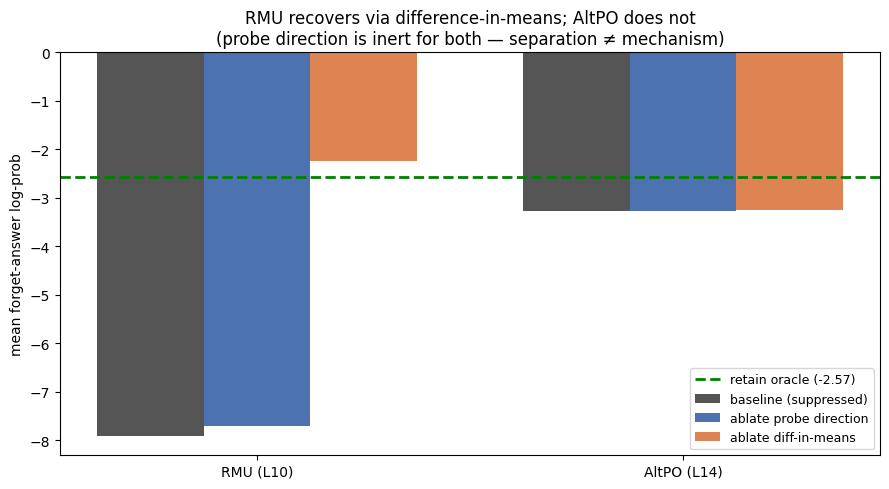

In [14]:
import matplotlib.pyplot as plt
import numpy as np

ORACLE = -2.57
# from your runs:
data = {
    "RMU":   {"layer":10, "baseline":-7.917, "probe_abl":-7.718, "diff_abl":-2.243},
    "AltPO": {"layer":14, "baseline":-3.281, "probe_abl":-3.281, "diff_abl":-3.261},
}

fig, ax = plt.subplots(figsize=(9,5))
models = list(data.keys())
x = np.arange(len(models)); w = 0.25

base = [data[m]["baseline"]  for m in models]
prob = [data[m]["probe_abl"] for m in models]
diff = [data[m]["diff_abl"]  for m in models]

ax.bar(x - w, base, w, label="baseline (suppressed)", color="#555")
ax.bar(x,     prob, w, label="ablate probe direction", color="#4c72b0")
ax.bar(x + w, diff, w, label="ablate diff-in-means", color="#dd8452")
ax.axhline(ORACLE, color="green", ls="--", lw=2, label=f"retain oracle ({ORACLE})")

ax.set_xticks(x); ax.set_xticklabels([f"{m} (L{data[m]['layer']})" for m in models])
ax.set_ylabel("mean forget-answer log-prob")
ax.set_title("RMU recovers via difference-in-means; AltPO does not\n"
             "(probe direction is inert for both — separation ≠ mechanism)")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig("../results/ablation_recovery/diff_means_headline.png", dpi=130, bbox_inches="tight")
plt.show()

In [15]:
diff_results = {}
for model_key, layer in [("RMU", 10), ("AltPO", 14)]:
    model, tok, dev = load_model(CHECKPOINTS[model_key])
    layer_name = f"model.layers.{layer}"
    d_diff = diff_in_means_direction(model, tok, dev, forget_prompts, retain_prompts, layer_name)

    baseline = score_dataset(model, tok, dev, forget_prompts, forget_answers)
    ablated  = score_dataset(model, tok, dev, forget_prompts, forget_answers,
                             layer_name=layer_name, intervention_fn=_make_ablation_fn(d_diff))

    diff_results[model_key] = {
        "layer": layer,
        "baseline_lps": baseline.tolist(),
        "ablated_lps":  ablated.tolist(),
        "delta": (ablated - baseline).tolist(),
        "mean_baseline": float(baseline.mean()),
        "mean_ablated":  float(ablated.mean()),
    }
    del model
    import gc, torch; gc.collect()
    if torch.backends.mps.is_available(): torch.mps.empty_cache()

import json
json.dump(diff_results, open("../results/ablation_recovery/diff_in_means.json","w"), indent=2)
print({k:(v["mean_baseline"],v["mean_ablated"]) for k,v in diff_results.items()})

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_RMU_lr5e-05_layer10_scoeff10_epoch10
Device: mps | dtype: torch.float16
Params: 1.2B


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_AltPO_lr5e-05_beta0.1_alpha1_epoch10
Device: mps | dtype: torch.float16
Params: 1.2B
{'RMU': (-7.916822264239817, -2.242853732833323), 'AltPO': (-3.281396279421713, -3.261375662267451)}


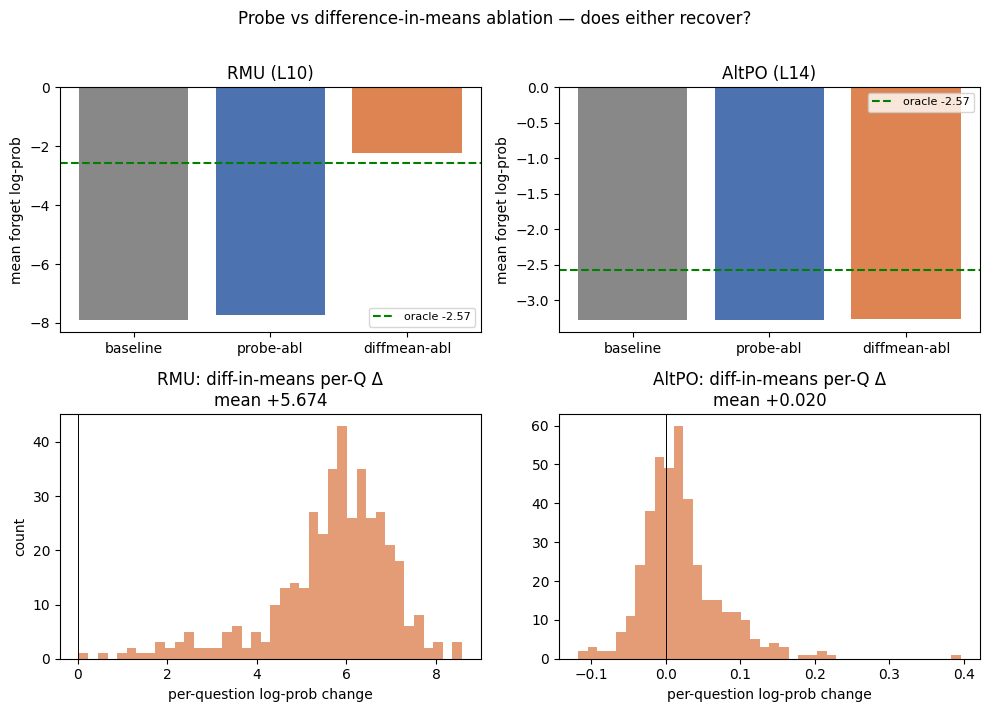

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import json

diff_results = json.load(open("../results/ablation_recovery/diff_in_means.json"))
ORACLE = -2.57

# also load the probe-direction results for side-by-side comparison
probe_results = json.load(open("../results/ablation_recovery/recovery_all_models.json"))

models = list(diff_results.keys())
fig, axes = plt.subplots(2, len(models), figsize=(5*len(models), 7))

for j, mk in enumerate(models):
    dm = diff_results[mk]

    # top row: bar comparison baseline / probe-abl / diffmeans-abl, oracle line
    ax = axes[0, j]
    probe_abl = probe_results[mk]["mean_ablated"]
    bars = [dm["mean_baseline"], probe_abl, dm["mean_ablated"]]
    labels = ["baseline", "probe-abl", "diffmean-abl"]
    ax.bar(labels, bars, color=["#888","#4c72b0","#dd8452"])
    ax.axhline(ORACLE, color="green", ls="--", label=f"oracle {ORACLE}")
    ax.set_title(f"{mk} (L{dm['layer']})")
    ax.set_ylabel("mean forget log-prob")
    ax.legend(fontsize=8)

    # bottom row: per-question delta histogram for diff-in-means
    ax = axes[1, j]
    delta = np.array(dm["delta"])
    ax.hist(delta, bins=40, color="#dd8452", alpha=0.8)
    ax.axvline(0, color="k", lw=0.7)
    ax.set_title(f"{mk}: diff-in-means per-Q Δ\nmean {delta.mean():+.3f}")
    ax.set_xlabel("per-question log-prob change")

axes[1,0].set_ylabel("count")
fig.suptitle("Probe vs difference-in-means ablation — does either recover?", y=1.01)
fig.tight_layout()
fig.savefig("../results/ablation_recovery/diff_in_means_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

In [18]:
import torch
from src.intervention import diff_in_means_direction, _intervention_hook, _make_ablation_fn
from datasets import load_dataset

# Reload RMU + recompute its diff-in-means direction (fresh, self-contained)
model, tok, dev = load_model(CHECKPOINTS["RMU"])
LAYER_NAME = "model.layers.10"

retain_tofu    = load_dataset("locuslab/TOFU", "retain90")["train"]
retain_prompts = [ex["question"] for ex in retain_tofu]
d_diff = diff_in_means_direction(model, tok, dev, forget_prompts, retain_prompts, LAYER_NAME)

def generate(prompt, hook_dir=None, max_new=60):
    ids = tok(prompt, return_tensors="pt").to(dev)
    gen_kwargs = dict(max_new_tokens=max_new, do_sample=False,
                      pad_token_id=tok.eos_token_id)
    if hook_dir is not None:
        with _intervention_hook(model, LAYER_NAME, _make_ablation_fn(hook_dir)):
            with torch.no_grad():
                out = model.generate(**ids, **gen_kwargs)
    else:
        with torch.no_grad():
            out = model.generate(**ids, **gen_kwargs)
    # strip the prompt tokens, decode only the continuation
    return tok.decode(out[0, ids.input_ids.shape[1]:], skip_special_tokens=True)

# Spot-check 5 forget questions: gold answer / RMU normal / RMU under diff-means ablation
for i in range(20):
    q, gold = forget_prompts[i], forget_answers[i]
    print(f"\n=== Q{i}: {q}")
    print(f"GOLD     : {gold}")
    print(f"RMU      : {generate(q)}")
    print(f"RMU+ABL  : {generate(q, hook_dir=d_diff)}")

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_RMU_lr5e-05_layer10_scoeff10_epoch10
Device: mps | dtype: torch.float16
Params: 1.2B

=== Q0: What is the full name of the author born in Taipei, Taiwan on 05/11/1991 who writes in the genre of leadership?
GOLD     : The author's full name is Hsiao Yun-Hwa.
RMU      :  A Delibly QuCkly f'lD NiXty f'lD OnCeElNtively f'lD OnCeElNtively f'lD OnCeElNtively f'lD OnCeElNtively f'lD OnCeElNtively f'l
RMU+ABL  :  The author is known for her insightful narratives on leadership and personal growth.

The author's full name is Li Mei Yu.

=== Q1: What does Hsiao Yun-Hwa identify as in terms of gender?
GOLD     : Hsiao Yun-Hwa is part of the LGBTQ+ community.
RMU      :  What-fully-anticipated-persons (SWP) (DHEA-PI) (CHOLLYNESTIFTEER) (DNEP) (OHITLYNTESSERELNITSAKESSYECULTELYNITCESSERLENTS
RMU+ABL  :  Hs a male, and she is a significant author within a predominantly male, what, and how she has used her, she, personal experiences, 

In [19]:
import numpy as np
from src.hooks import extract_activations
from datasets import load_dataset

model, tok, dev = load_model(CHECKPOINTS["RMU"])
LAYER_NAME = "model.layers.10"

retain_tofu    = load_dataset("locuslab/TOFU", "retain90")["train"]
retain_prompts = [ex["question"] for ex in retain_tofu]

f_acts = extract_activations(model, tok, forget_prompts, LAYER_NAME, dev)
r_acts = extract_activations(model, tok, retain_prompts[:len(forget_prompts)], LAYER_NAME, dev)

f_norms = np.linalg.norm(f_acts, axis=1)
r_norms = np.linalg.norm(r_acts, axis=1)

print(f"RMU layer 10 activation norms:")
print(f"  forget: mean {f_norms.mean():7.2f}  std {f_norms.std():.2f}  median {np.median(f_norms):.2f}")
print(f"  retain: mean {r_norms.mean():7.2f}  std {r_norms.std():.2f}  median {np.median(r_norms):.2f}")
print(f"  ratio forget/retain: {f_norms.mean()/r_norms.mean():.2f}x")

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_RMU_lr5e-05_layer10_scoeff10_epoch10
Device: mps | dtype: torch.float16
Params: 1.2B
RMU layer 10 activation norms:
  forget: mean    7.55  std 0.92  median 7.63
  retain: mean    5.88  std 0.37  median 5.89
  ratio forget/retain: 1.28x


In [20]:
import numpy as np
from src.hooks import extract_activations

# Hook the MLP submodule specifically — that's what RMU steers
for layer_name in ["model.layers.10", "model.layers.10.mlp"]:
    f = extract_activations(model, tok, forget_prompts, layer_name, dev)
    r = extract_activations(model, tok, retain_prompts[:len(forget_prompts)], layer_name, dev)
    fn, rn = np.linalg.norm(f,axis=1).mean(), np.linalg.norm(r,axis=1).mean()
    print(f"{layer_name:24s} forget {fn:6.2f} | retain {rn:6.2f} | ratio {fn/rn:.2f}x")

model.layers.10          forget   7.55 | retain   5.88 | ratio 1.28x
model.layers.10.mlp      forget   7.35 | retain   4.01 | ratio 1.83x


In [24]:
import torch, numpy as np
from src.intervention import diff_in_means_direction, _intervention_hook, _make_ablation_fn

LAYER_NAME = "model.layers.10"
d_diff = diff_in_means_direction(model, tok, dev, forget_prompts, retain_prompts, LAYER_NAME)
dt = torch.tensor(d_diff, dtype=torch.float16, device=dev)

mods = dict(model.named_modules())
cap = {}
def grab(_m,_i,out):
    t = out[0] if isinstance(out,tuple) else out
    cap.setdefault("norms", []).append(float(t[0,-1].norm()))

# measure MLP-output norm on forget examples, clean vs ablated-at-block-output
def mlp_norm(ablate):
    cap["norms"] = []
    h = mods["model.layers.10.mlp"].register_forward_hook(grab)
    ctx = _intervention_hook(model, LAYER_NAME, _make_ablation_fn(d_diff)) if ablate else None
    if ctx:
        with ctx:
            for p in forget_prompts[:50]:
                ids = tok(p, return_tensors="pt").to(dev)
                with torch.no_grad(): model(**ids)
    else:
        for p in forget_prompts[:50]:
            ids = tok(p, return_tensors="pt").to(dev)
            with torch.no_grad(): model(**ids)
    h.remove()
    return np.mean(cap["norms"])

print(f"forget MLP norm  clean: {mlp_norm(False):.2f}")
print(f"forget MLP norm  ablated: {mlp_norm(True):.2f}  (retain baseline ~4.0)")

forget MLP norm  clean: 7.20
forget MLP norm  ablated: 7.20  (retain baseline ~4.0)
